In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,precision_score, recall_score
from sklearn import tree


In [3]:
df = pd.read_csv('Datasets/PlayTennis.csv')
print(df.head())


    outlook  temp humidity  windy play
0     sunny   hot     high  False   no
1     sunny   hot     high   True   no
2  overcast   hot     high  False  yes
3     rainy  mild     high  False  yes
4     rainy  cool   normal  False  yes


In [4]:
y = df[['play']]
x = df.drop('play', axis=1)

In [5]:
print(x,y)

     outlook  temp humidity  windy
0      sunny   hot     high  False
1      sunny   hot     high   True
2   overcast   hot     high  False
3      rainy  mild     high  False
4      rainy  cool   normal  False
5      rainy  cool   normal   True
6   overcast  cool   normal   True
7      sunny  mild     high  False
8      sunny  cool   normal  False
9      rainy  mild   normal  False
10     sunny  mild   normal   True
11  overcast  mild     high   True
12  overcast   hot   normal  False
13     rainy  mild     high   True    play
0    no
1    no
2   yes
3   yes
4   yes
5    no
6   yes
7    no
8   yes
9   yes
10  yes
11  yes
12  yes
13   no


In [6]:
x = pd.get_dummies(x,drop_first=True)

In [7]:
DT = DecisionTreeClassifier(criterion='entropy',random_state=10,max_depth=3)

In [8]:
DT

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [10]:
DT.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
y_pred = DT.predict(x_test)

In [12]:
pridiction = pd.DataFrame({'Actual':y_test.squeeze(),'Predicted':y_pred.squeeze()})

In [13]:
pridiction

,Actual,Predicted
3,yes,no
7,no,no
12,yes,yes


[Text(0.5, 0.875, 'x[5] <= 0.5\nentropy = 0.946\nsamples = 11\nvalue = [4, 7]'),
 Text(0.3, 0.625, 'x[2] <= 0.5\nentropy = 0.971\nsamples = 5\nvalue = [3, 2]'),
 Text(0.4, 0.75, 'True  '),
 Text(0.2, 0.375, 'x[1] <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2]'),
 Text(0.1, 0.125, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.375, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.7, 0.625, 'x[1] <= 0.5\nentropy = 0.65\nsamples = 6\nvalue = [1, 5]'),
 Text(0.6, 0.75, '  False'),
 Text(0.6, 0.375, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.375, 'x[0] <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2]'),
 Text(0.7, 0.125, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.9, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]')]

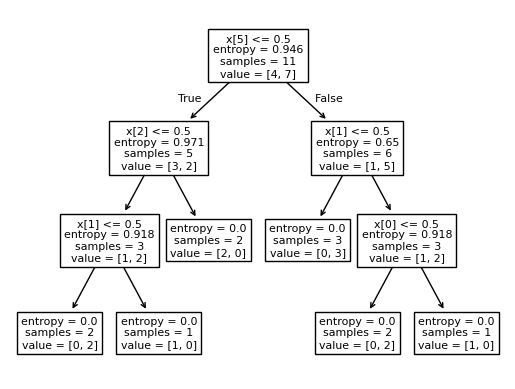

In [14]:
tree.plot_tree(DT)


In [15]:
conf_matrix = confusion_matrix(y_test,y_pred)
conf_matrix

array([[1, 0],
       [1, 1]])

Text(0.5, 1.0, 'Confusion Matrix Heatmap')

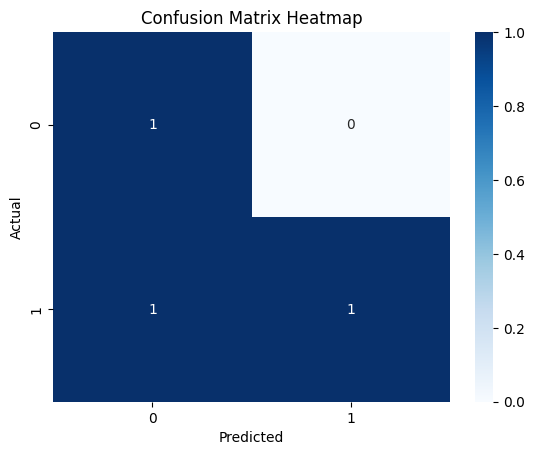

In [19]:
sns.heatmap(conf_matrix, annot=True,  cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')

In [22]:
DT.predict([[True,True,False,True,False,True]])

c:\Users\ADM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['no'], dtype=object)

In [21]:
x

,windy,outlook_rainy,outlook_sunny,temp_hot,temp_mild,humidity_normal
0,False,False,True,True,False,False
1,True,False,True,True,False,False
2,False,False,False,True,False,False
3,False,True,False,False,True,False
4,False,True,False,False,False,True
5,True,True,False,False,False,True
6,True,False,False,False,False,True
7,False,False,True,False,True,False
8,False,False,True,False,False,True
9,False,True,False,False,True,True


In [23]:
df = pd.read_csv('Datasets/drug200.csv')
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [27]:
y = df[['Drug']]

In [28]:
x= df.drop('Drug', axis=1)

In [30]:
y,x

(      Drug
 0    drugY
 1    drugC
 2    drugC
 3    drugX
 4    drugY
 ..     ...
 195  drugC
 196  drugC
 197  drugX
 198  drugX
 199  drugX
 
 [200 rows x 1 columns],
      Age Sex      BP Cholesterol  Na_to_K
 0     23   F    HIGH        HIGH   25.355
 1     47   M     LOW        HIGH   13.093
 2     47   M     LOW        HIGH   10.114
 3     28   F  NORMAL        HIGH    7.798
 4     61   F     LOW        HIGH   18.043
 ..   ...  ..     ...         ...      ...
 195   56   F     LOW        HIGH   11.567
 196   16   M     LOW        HIGH   12.006
 197   52   M  NORMAL        HIGH    9.894
 198   23   M  NORMAL      NORMAL   14.020
 199   40   F     LOW      NORMAL   11.349
 
 [200 rows x 5 columns])

In [31]:
x = pd.get_dummies(x,drop_first=True)

In [32]:
x

,Age,Na_to_K,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,False,False,False,False
1,47,13.093,True,True,False,False
2,47,10.114,True,True,False,False
3,28,7.798,False,False,True,False
4,61,18.043,False,True,False,False
...,...,...,...,...,...,...
195,56,11.567,False,True,False,False
196,16,12.006,True,True,False,False
197,52,9.894,True,False,True,False
198,23,14.020,True,False,True,True


In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [44]:
DT = DecisionTreeClassifier(criterion='entropy',random_state=10,max_depth=10)

In [45]:
DT.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
y_pred = DT.predict(x_test)

In [47]:
y_pred

array(['drugY', 'drugX', 'drugY', 'drugX', 'drugY', 'drugY', 'drugX',
       'drugC', 'drugY', 'drugC', 'drugY', 'drugC', 'drugY', 'drugB',
       'drugB', 'drugX', 'drugY', 'drugA', 'drugX', 'drugY', 'drugY',
       'drugY', 'drugA', 'drugY', 'drugC', 'drugY', 'drugB', 'drugC',
       'drugC', 'drugY', 'drugX', 'drugX', 'drugA', 'drugY', 'drugX',
       'drugY', 'drugX', 'drugA', 'drugA', 'drugA'], dtype=object)

In [48]:
pridiction = pd.DataFrame({'Actual':y_test.squeeze(),'Predicted':y_pred.squeeze()})

[Text(0.75, 0.9, 'x[1] <= 14.829\nentropy = 1.915\nsamples = 160\nvalue = [17, 13, 10, 45, 75]'),
 Text(0.625, 0.7, 'x[4] <= 0.5\nentropy = 1.728\nsamples = 85\nvalue = [17.0, 13.0, 10.0, 45.0, 0.0]'),
 Text(0.6875, 0.8, 'True  '),
 Text(0.5, 0.5, 'x[3] <= 0.5\nentropy = 1.971\nsamples = 56\nvalue = [17, 13, 10, 16, 0]'),
 Text(0.25, 0.3, 'x[0] <= 50.5\nentropy = 0.987\nsamples = 30\nvalue = [17, 13, 0, 0, 0]'),
 Text(0.125, 0.1, 'entropy = 0.0\nsamples = 17\nvalue = [17, 0, 0, 0, 0]'),
 Text(0.375, 0.1, 'entropy = 0.0\nsamples = 13\nvalue = [0, 13, 0, 0, 0]'),
 Text(0.75, 0.3, 'x[5] <= 0.5\nentropy = 0.961\nsamples = 26\nvalue = [0, 0, 10, 16, 0]'),
 Text(0.625, 0.1, 'entropy = 0.0\nsamples = 10\nvalue = [0, 0, 10, 0, 0]'),
 Text(0.875, 0.1, 'entropy = 0.0\nsamples = 16\nvalue = [0, 0, 0, 16, 0]'),
 Text(0.75, 0.5, 'entropy = 0.0\nsamples = 29\nvalue = [0, 0, 0, 29, 0]'),
 Text(0.875, 0.7, 'entropy = 0.0\nsamples = 75\nvalue = [0, 0, 0, 0, 75]'),
 Text(0.8125, 0.8, '  False')]

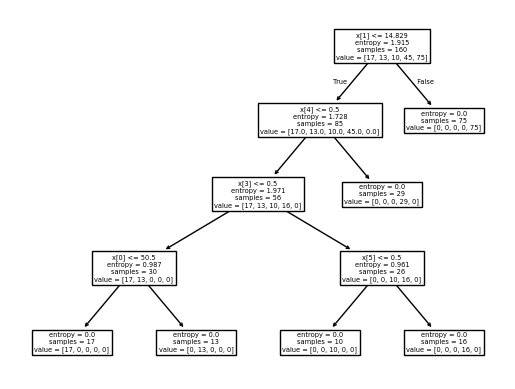

In [49]:
tree.plot_tree(DT)
